Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 6,024,884 (22.98 MB)

 Trainable params: 658,437 (2.51 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 1,316,876 (5.02 MB)

                precision    recall  f1-score   support

         No_DR       0.92      0.92      0.92       351
          Mild       0.37      0.32      0.34        68
      Moderate       0.62      0.73      0.67       213
        Severe       0.24      0.17      0.20        36
Proliferate_DR       0.18      0.12      0.15        65

      accuracy                           0.70       733
     macro avg       0.46      0.45      0.46       733
  weighted avg       0.68      0.70      0.69       733



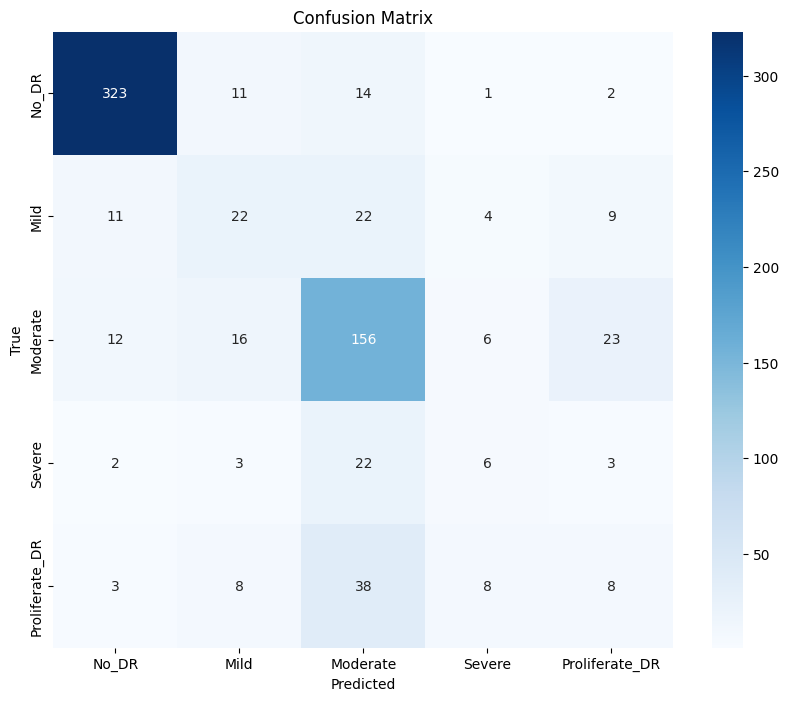

In [1]:
import numpy as np
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_data, preprocess_image

# Load the pre-trained EfficientNet model
def load_EfficientNet_model(model_path):
    model = tf.keras.models.load_model(model_path)
    model.summary()
    return model

# Extract features from a chosen convolutional layer
def extract_features(model, img_array, layer_name='top_conv'):
    feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.get_layer(layer_name).output)
    features = feature_extractor(img_array)
    return features.numpy().flatten()

# Train a Decision Tree classifier as a surrogate
def train_decision_tree(features, original_predictions, decision_tree):
    decision_tree.fit(features, original_predictions)
    return decision_tree

# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Main workflow to train Decision Tree and explain EfficientNet
def explain_EfficientNet_with_decision_tree(X_train, X_test, y_train, y_test, model_path, csv_file, base_image_dir, decision_tree):
    model = load_EfficientNet_model(model_path)
    
    # Prepare data
    # X_train, X_test, y_train, y_test = load_data(csv_file, base_image_dir)
    feature_list_train = []
    feature_list_test = []
    
    # Extract features for training data
    for img_path in X_train:
        img_array = preprocess_image(img_path)
        features = extract_features(model, img_array)
        feature_list_train.append(features)
    
    # Extract features for testing data
    for img_path in X_test:
        img_array = preprocess_image(img_path)
        features = extract_features(model, img_array)
        feature_list_test.append(features)
    
    # Train a Decision Tree using extracted features
    decision_tree = train_decision_tree(feature_list_train, y_train, decision_tree)
    
    # Make predictions on the test set
    y_pred = decision_tree.predict(feature_list_test)
    
    # Evaluate the model
    class_names = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
    print(classification_report(y_test, y_pred, target_names=class_names))
    
    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred, class_names)

# Usage
model_path = '../models/efficientnet_model.keras'  # Path to your trained EfficientNet model
csv_file = '../archive/train.csv'  # Path to your dataset CSV
base_image_dir = '../archive/gaussian_filtered_images'  # Path to your image directory
decision_tree = DecisionTreeClassifier(max_depth=10, random_state=42)
X_train, X_test, y_train, y_test = load_data(csv_file, base_image_dir)

explain_EfficientNet_with_decision_tree(X_train, X_test, y_train, y_test, model_path, csv_file, base_image_dir, decision_tree)


In [2]:
import joblib

# Save the trained Decision Tree model
model_save_path = '../models/efficientnet_beta.pkl'
joblib.dump(decision_tree, model_save_path)

print(f"Decision Tree model saved at {model_save_path}")

Decision Tree model saved at ../models/efficientnet_beta.pkl


In [3]:
import joblib
import numpy as np
from sklearn.metrics import accuracy_score

# Load the Decision Tree model
decision_tree_path = '../models/efficientnet_beta.pkl'
decision_tree = joblib.load(decision_tree_path)

# Load the EfficientNet model
EfficientNet_model_path = '../models/efficientnet_model.keras'
EfficientNet_model = tf.keras.models.load_model(EfficientNet_model_path)

# Function to calculate fidelity
def calculate_fidelity(EfficientNet_model, decision_tree, X_test):
    EfficientNet_predictions = []
    decision_tree_predictions = []
    
    # Get predictions from both models
    for img_path in X_test:
        img_array = preprocess_image(img_path)
        
        # EfficientNet predictions
        EfficientNet_pred = EfficientNet_model.predict(img_array)
        EfficientNet_predictions.append(np.argmax(EfficientNet_pred))
        
        # Decision Tree predictions
        features = extract_features(EfficientNet_model, img_array)
        decision_tree_pred = decision_tree.predict([features])[0]
        decision_tree_predictions.append(decision_tree_pred)
    
    # Calculate fidelity as accuracy of decision tree mimicking EfficientNet
    fidelity = accuracy_score(EfficientNet_predictions, decision_tree_predictions)
    return fidelity

# Function to calculate unambiguity (using depth of the tree)
def calculate_unambiguity(decision_tree):
    tree_depth = decision_tree.get_depth()
    return 1 / (tree_depth + 1)  # Higher depth = lower unambiguity

# Function to calculate interpretability (using number of nodes)
def calculate_interpretability(decision_tree):
    num_nodes = decision_tree.tree_.node_count
    return 1 / (num_nodes + 1)  # Fewer nodes = higher interpretability

# Example of calculating metrics
fidelity = calculate_fidelity(EfficientNet_model, decision_tree, X_test)  # X_test should be the test dataset paths
unambiguity = calculate_unambiguity(decision_tree)
interpretability = calculate_interpretability(decision_tree)

print(f"Fidelity: {fidelity}")
print(f"Unambiguity: {unambiguity}")
print(f"Interpretability: {interpretability}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━